✅ All data loaded!


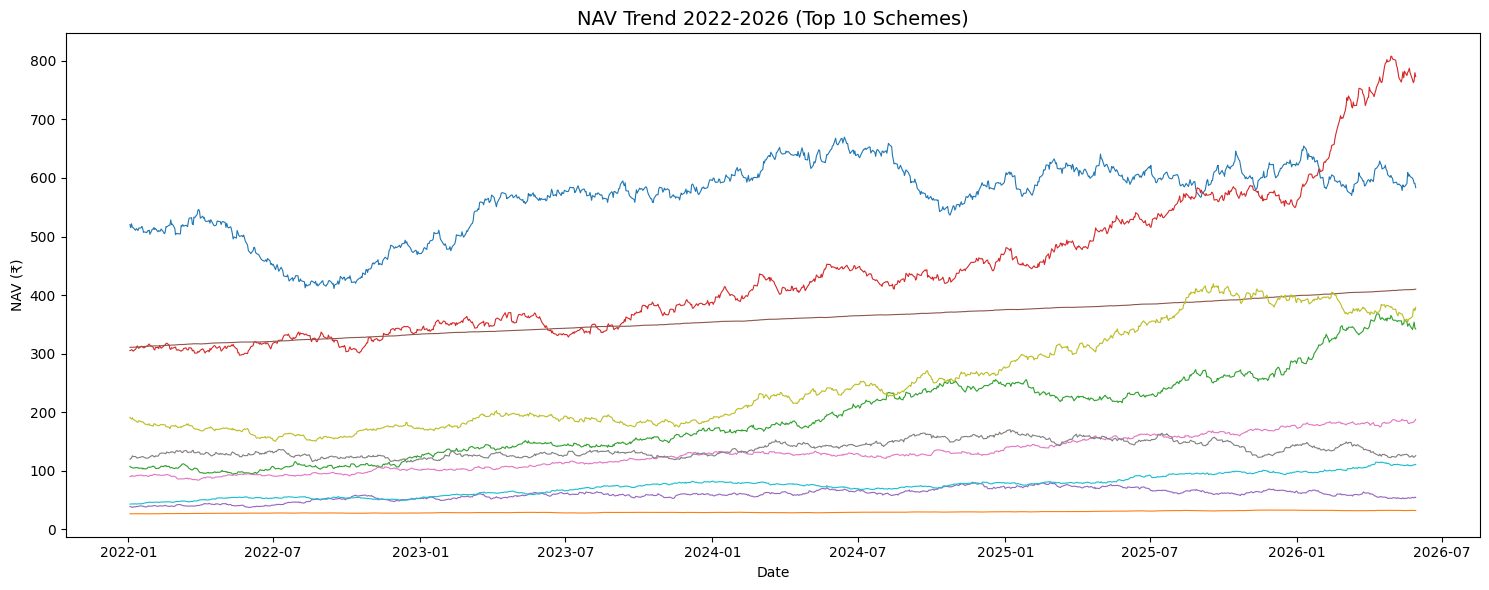

✅ Chart 1 saved!


In [51]:
# Cell 1+2 Combined - Imports + NAV Trend
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('reports', exist_ok=True)

# Load data
nav_df = pd.read_csv('data/processed/nav_history_clean.csv')
trans_df = pd.read_csv('data/processed/investor_transactions_clean.csv')
perf_df = pd.read_csv('data/processed/scheme_performance_clean.csv')
aum_df = pd.read_csv('data/raw/03_aum_by_fund_house.csv')
sip_df = pd.read_csv('data/raw/04_monthly_sip_inflows.csv')

print("✅ All data loaded!")

# NAV Trend Chart
nav_df['date'] = pd.to_datetime(nav_df['date'])

plt.figure(figsize=(15, 6))
for code in nav_df['amfi_code'].unique()[:10]:
    data = nav_df[nav_df['amfi_code'] == code]
    plt.plot(data['date'], data['nav'], linewidth=0.8)

plt.title('NAV Trend 2022-2026 (Top 10 Schemes)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('NAV (₹)')
plt.tight_layout()
plt.savefig('reports/nav_trend.png', dpi=150)
plt.show()
print("✅ Chart 1 saved!")



AUM Columns: ['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216


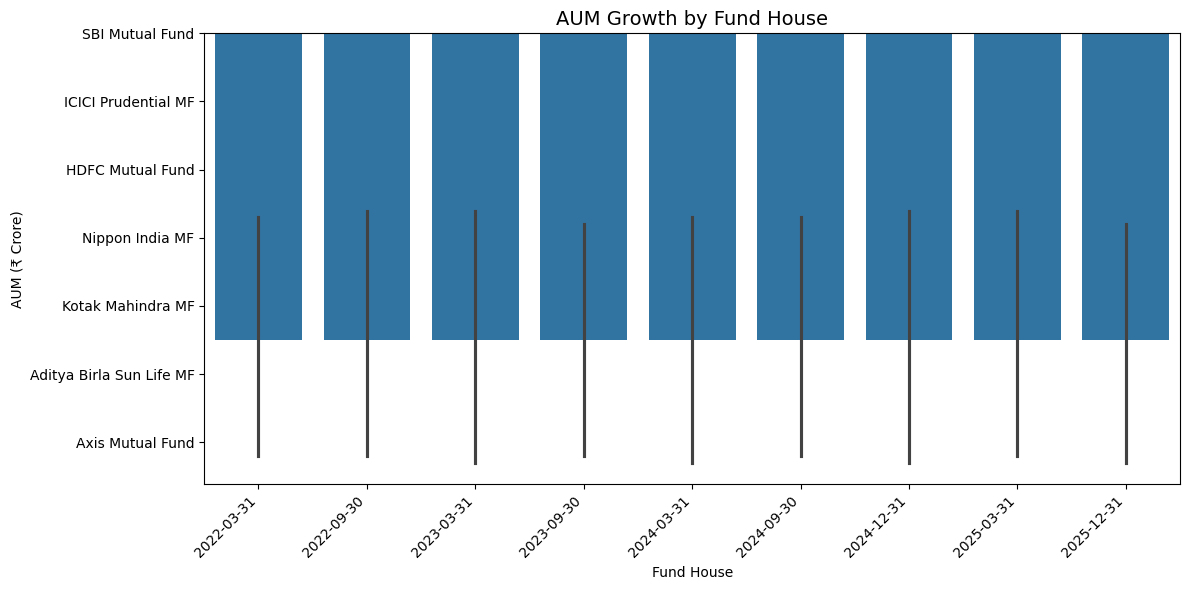

✅ Chart 2 saved!


In [52]:
# Cell 2 - AUM Growth Bar Chart by Fund House
print("AUM Columns:", aum_df.columns.tolist())
print(aum_df.head(2))

plt.figure(figsize=(12, 6))
sns.barplot(data=aum_df, 
            x=aum_df.columns[0], 
            y=aum_df.columns[1])

plt.title('AUM Growth by Fund House', fontsize=14)
plt.xlabel('Fund House')
plt.ylabel('AUM (₹ Crore)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('reports/aum_growth.png', dpi=150)
plt.show()
print("✅ Chart 2 saved!")

SIP Columns: ['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                    9.1                4.80             NaN  
1                    8.2                4.85             NaN  


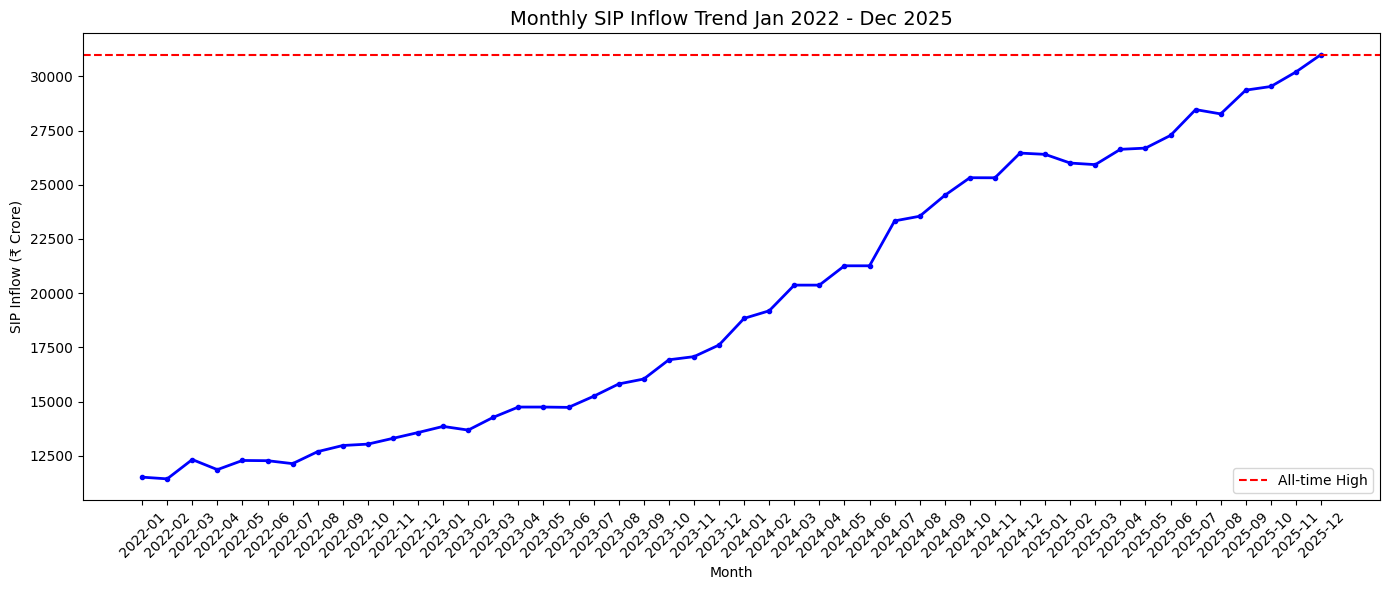

✅ Chart 3 saved!


In [53]:
# Cell 3 - SIP Inflow Time Series
print("SIP Columns:", sip_df.columns.tolist())
print(sip_df.head(2))

sip_df['date'] = pd.to_datetime(sip_df.iloc[:, 0])

plt.figure(figsize=(14, 6))
plt.plot(sip_df.iloc[:, 0], 
         sip_df.iloc[:, 1], 
         color='blue', linewidth=2, marker='o', markersize=3)

plt.title('Monthly SIP Inflow Trend Jan 2022 - Dec 2025', fontsize=14)
plt.xlabel('Month')
plt.ylabel('SIP Inflow (₹ Crore)')
plt.xticks(rotation=45)
plt.axhline(y=sip_df.iloc[:, 1].max(), 
            color='red', linestyle='--', label='All-time High')
plt.legend()
plt.tight_layout()
plt.savefig('reports/sip_trend.png', dpi=150)
plt.show()
print("✅ Chart 3 saved!")

Category Columns: ['month', 'category', 'net_inflow_crore']
     month   category  net_inflow_crore
0  2024-04  Large Cap            2413.0
1  2024-04    Mid Cap            3897.0


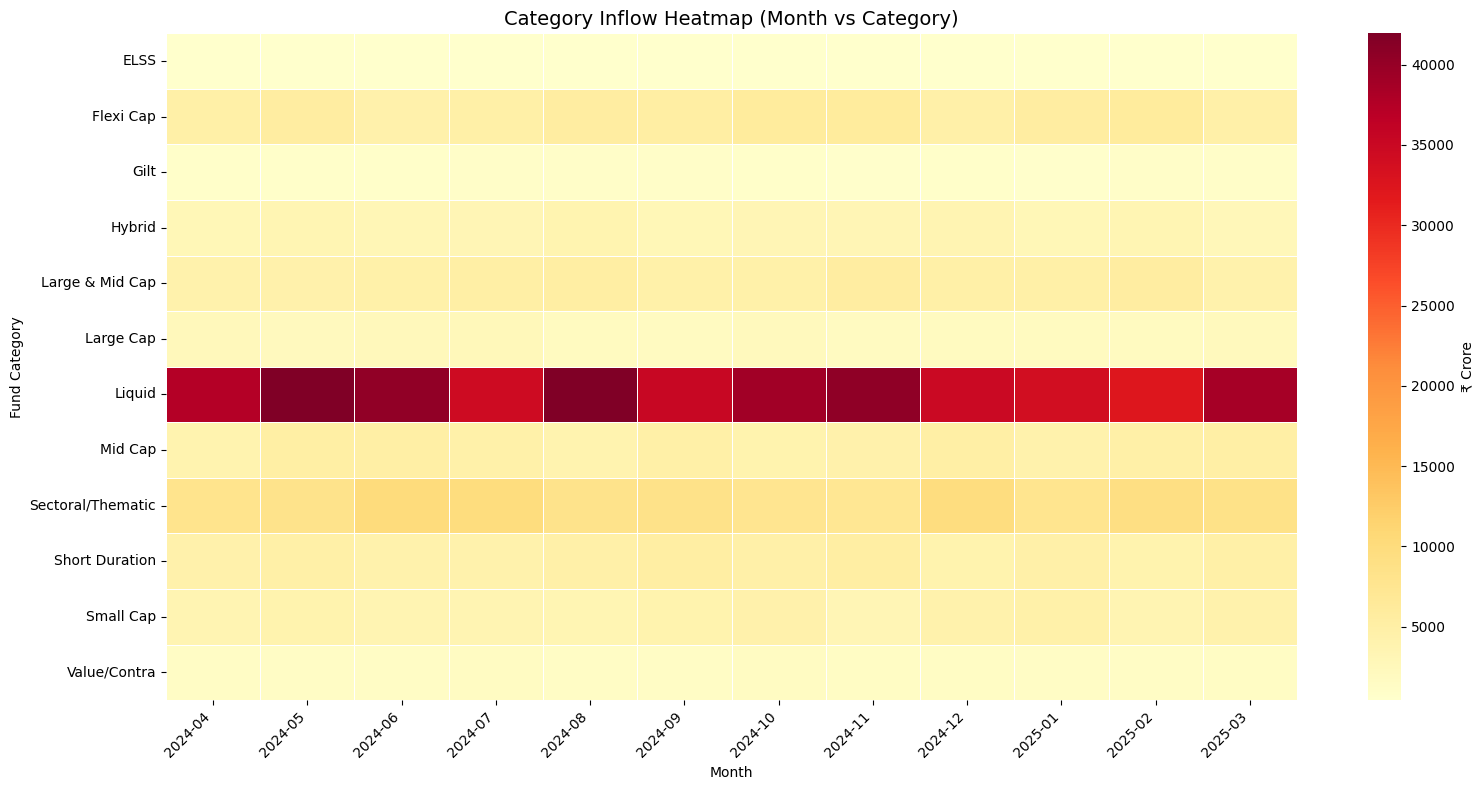

✅ Chart 4 saved!


In [54]:
# Cell 4 - Category Inflow Heatmap
cat_df = pd.read_csv('data/raw/05_category_inflows.csv')
print("Category Columns:", cat_df.columns.tolist())
print(cat_df.head(2))

# Create pivot table for heatmap
pivot = cat_df.pivot_table(
    index=cat_df.columns[1],  # category
    columns=cat_df.columns[0],  # month
    values=cat_df.columns[2],  # inflow value
    aggfunc='sum'
)

plt.figure(figsize=(16, 8))
sns.heatmap(pivot, 
            cmap='YlOrRd',
            annot=False,
            linewidths=0.5,
            cbar_kws={'label': '₹ Crore'})

plt.title('Category Inflow Heatmap (Month vs Category)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Fund Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('reports/category_heatmap.png', dpi=150)
plt.show()
print("✅ Chart 4 saved!")


Transaction Columns: ['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


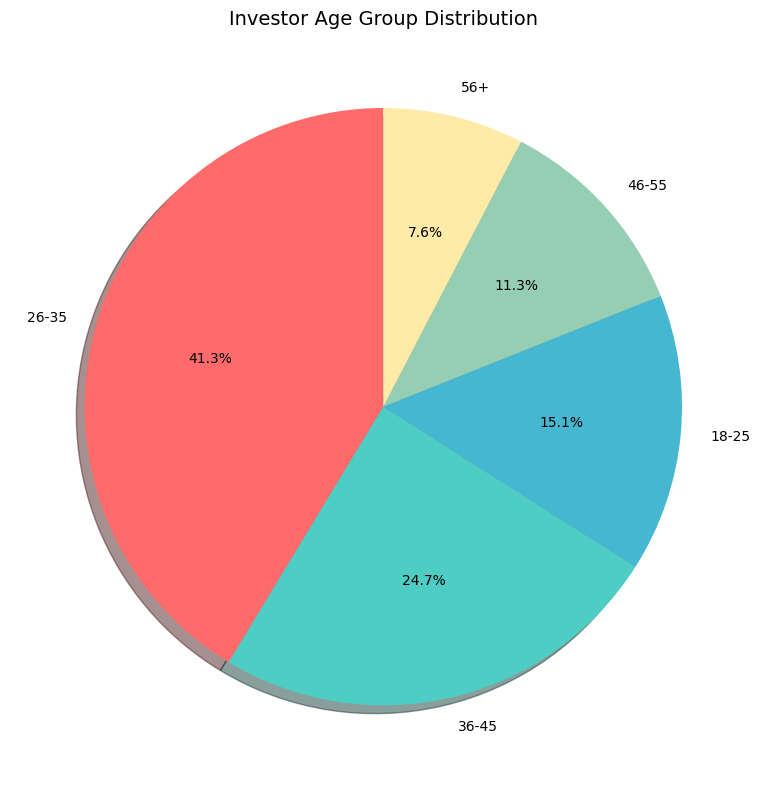

✅ Chart 5 saved!


In [55]:
# Cell 5 - Investor Age Group Distribution Pie Chart
print("Transaction Columns:", trans_df.columns.tolist())

age_counts = trans_df['age_group'].value_counts()

plt.figure(figsize=(10, 8))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
plt.pie(age_counts.values,
        labels=age_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        shadow=True)

plt.title('Investor Age Group Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('reports/age_distribution.png', dpi=150)
plt.show()
print("✅ Chart 5 saved!")

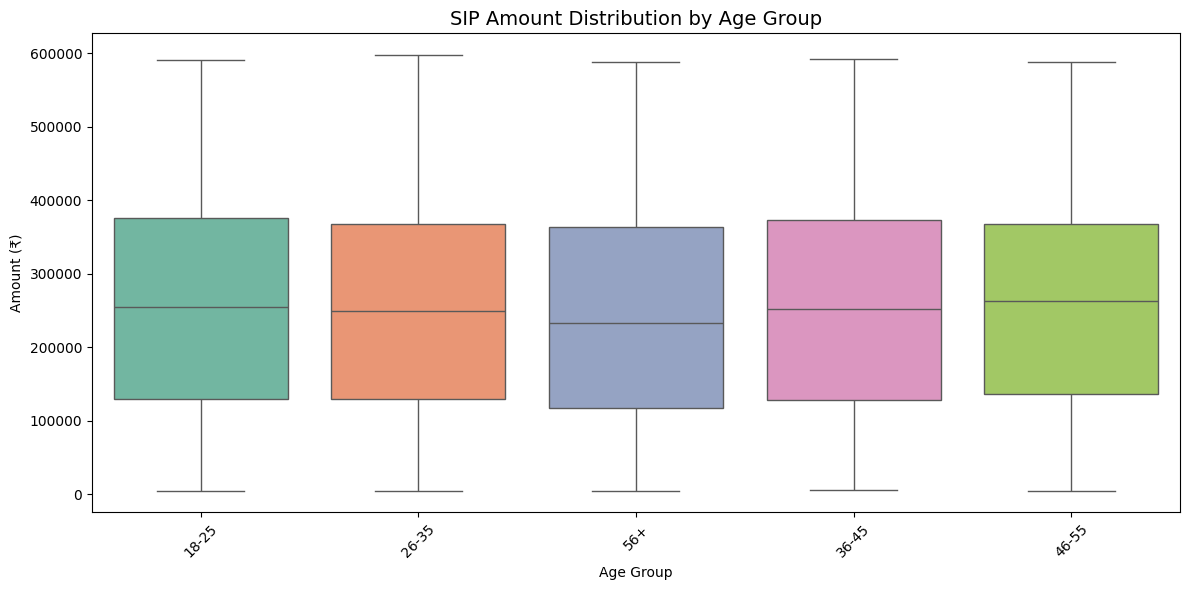

✅ Chart 6 saved!


In [56]:
# Cell 6 - SIP Amount Box Plot by Age Group
plt.figure(figsize=(12, 6))
sns.boxplot(data=trans_df, 
            x='age_group', 
            y='amount_inr',
            palette='Set2')

plt.title('SIP Amount Distribution by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Amount (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('reports/sip_boxplot.png', dpi=150)
plt.show()
print("✅ Chart 6 saved!")

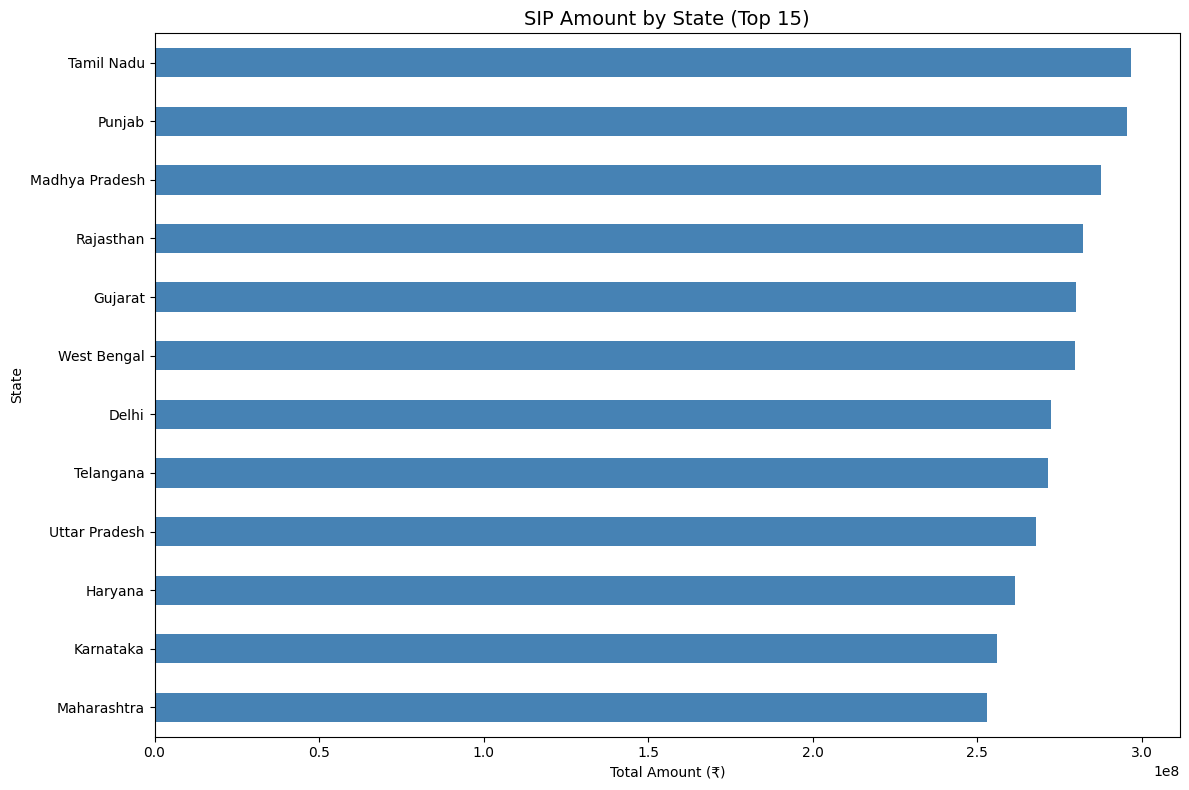

✅ Chart 7 saved!


In [57]:
# Cell 7 - Transactions by State
state_data = trans_df.groupby('state')['amount_inr'].sum().sort_values(ascending=True).tail(15)

plt.figure(figsize=(12, 8))
state_data.plot(kind='barh', color='steelblue')

plt.title('SIP Amount by State (Top 15)', fontsize=14)
plt.xlabel('Total Amount (₹)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig('reports/geographic_distribution.png', dpi=150)
plt.show()
print("✅ Chart 7 saved!")

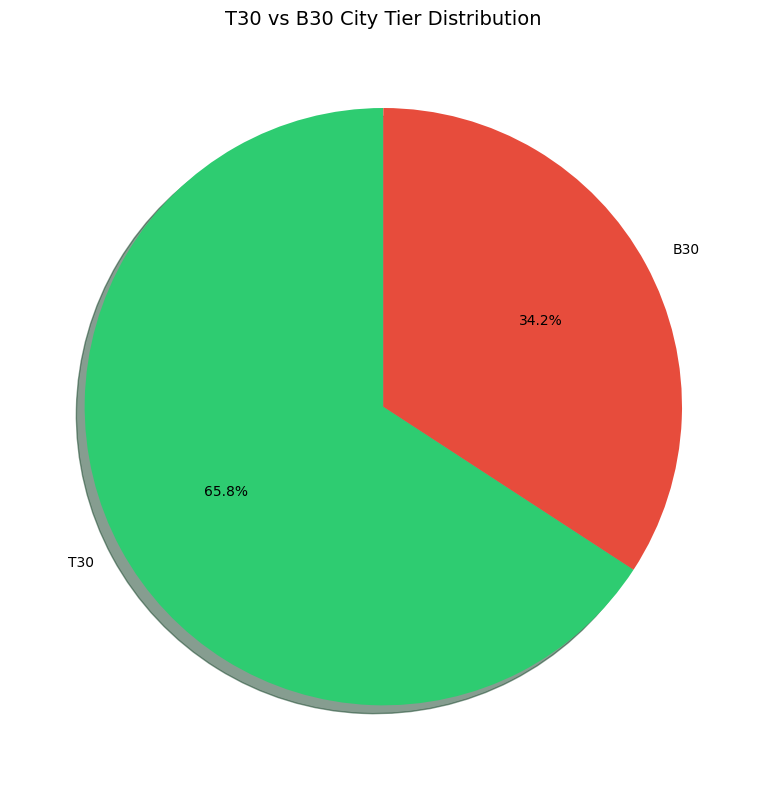

✅ Chart 8 saved!


In [58]:
# Cell 8 - T30 vs B30 City Tier
city_counts = trans_df['city_tier'].value_counts()

plt.figure(figsize=(8, 8))
colors = ['#2ECC71', '#E74C3C', '#3498DB']
plt.pie(city_counts.values,
        labels=city_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        shadow=True)

plt.title('T30 vs B30 City Tier Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('reports/city_tier.png', dpi=150)
plt.show()
print("✅ Chart 8 saved!")

Folio Columns: ['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


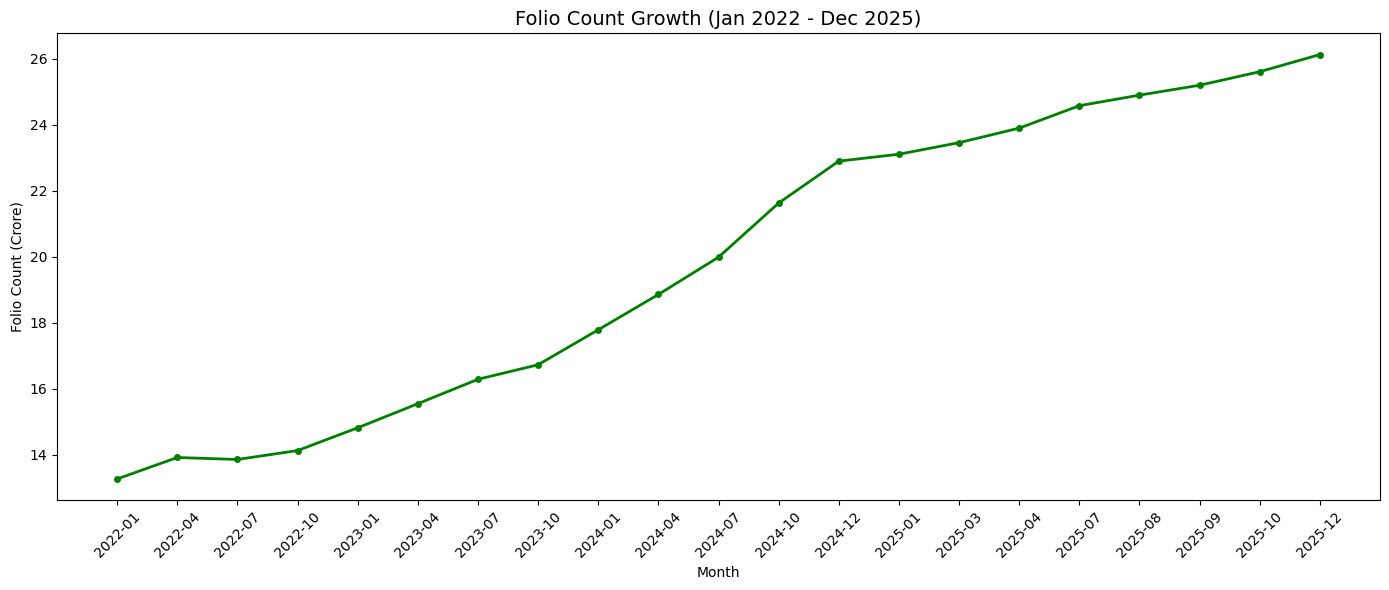

✅ Chart 9 saved!


In [59]:
# Cell 9 - Folio Count Growth Line Chart
folio_df = pd.read_csv('data/raw/06_industry_folio_count.csv')
print("Folio Columns:", folio_df.columns.tolist())

plt.figure(figsize=(14, 6))
plt.plot(folio_df.iloc[:, 0], 
         folio_df.iloc[:, 1],
         color='green', linewidth=2, 
         marker='o', markersize=4)

plt.title('Folio Count Growth (Jan 2022 - Dec 2025)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Folio Count (Crore)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('reports/folio_growth.png', dpi=150)
plt.show()
print("✅ Chart 9 saved!")

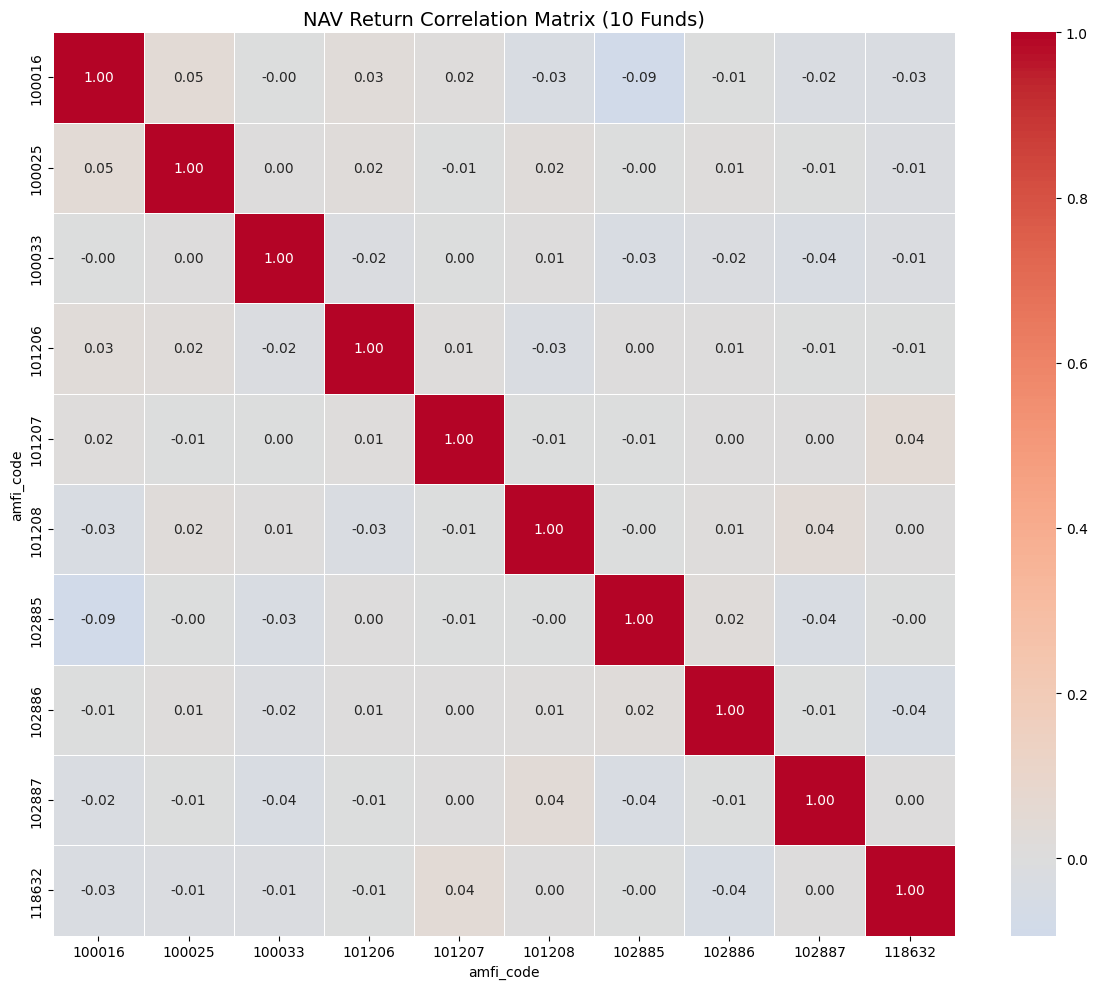

✅ Chart 10 saved!


In [60]:
# Cell 10 - NAV Return Correlation Heatmap
top_funds = nav_df['amfi_code'].unique()[:10]
pivot_nav = nav_df[nav_df['amfi_code'].isin(top_funds)].pivot_table(
    index='date', 
    columns='amfi_code', 
    values='nav'
)

returns = pivot_nav.pct_change().dropna()
correlation = returns.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5)

plt.title('NAV Return Correlation Matrix (10 Funds)', fontsize=14)
plt.tight_layout()
plt.savefig('reports/correlation_heatmap.png', dpi=150)
plt.show()
print("✅ Chart 10 saved!")

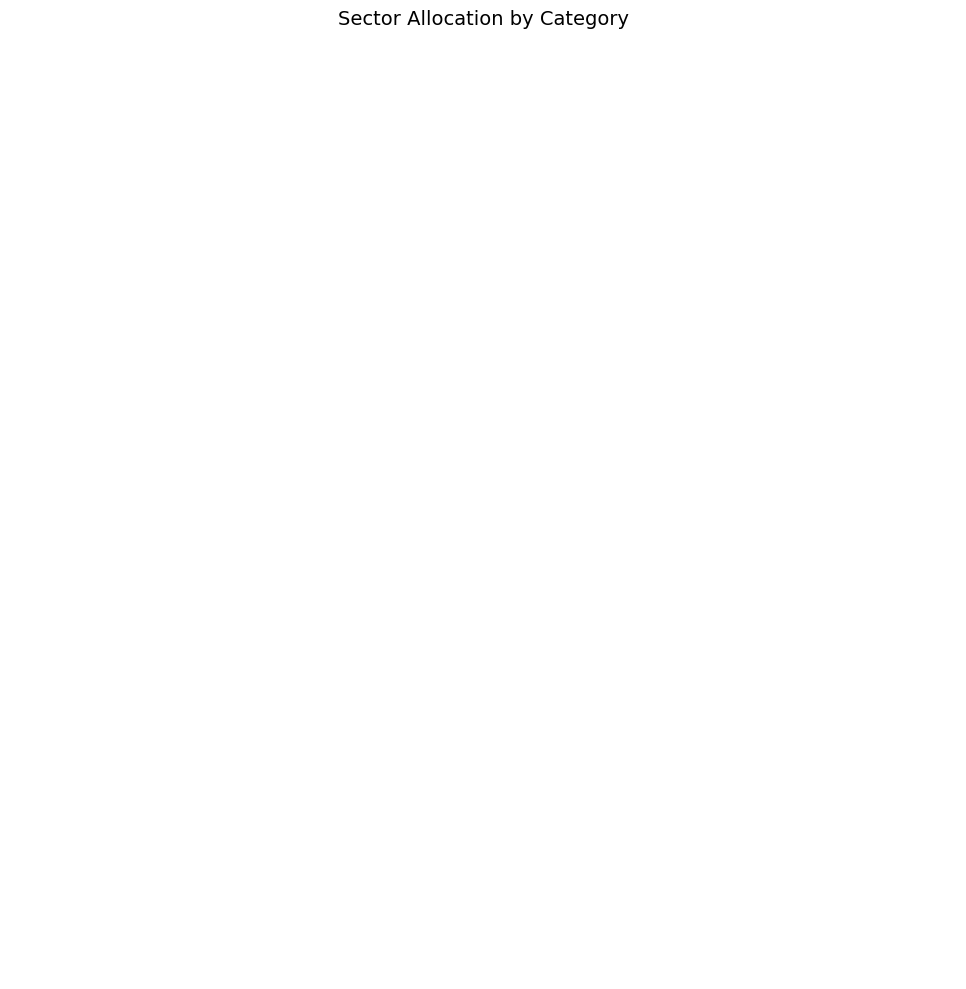

✅ Chart 11 saved!


In [66]:
# Cell 11 - Sector Allocation Donut Chart
category_aum = perf_df.groupby('category')['aum_crore'].sum()

plt.figure(figsize=(10, 10))
colors = plt.cm.Set3.colors
wedges, texts, autotexts = plt.pie(
    category_aum.values,
    labels=category_aum.index,
    autopct='%1.1f%%',
    colors=colors,
    pctdistance=0.85,
    startangle=90
)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title('Sector Allocation by Category', fontsize=14)
plt.tight_layout()
plt.savefig('reports/sector_donut.png', dpi=150)
plt.show()
print("✅ Chart 11 saved!")

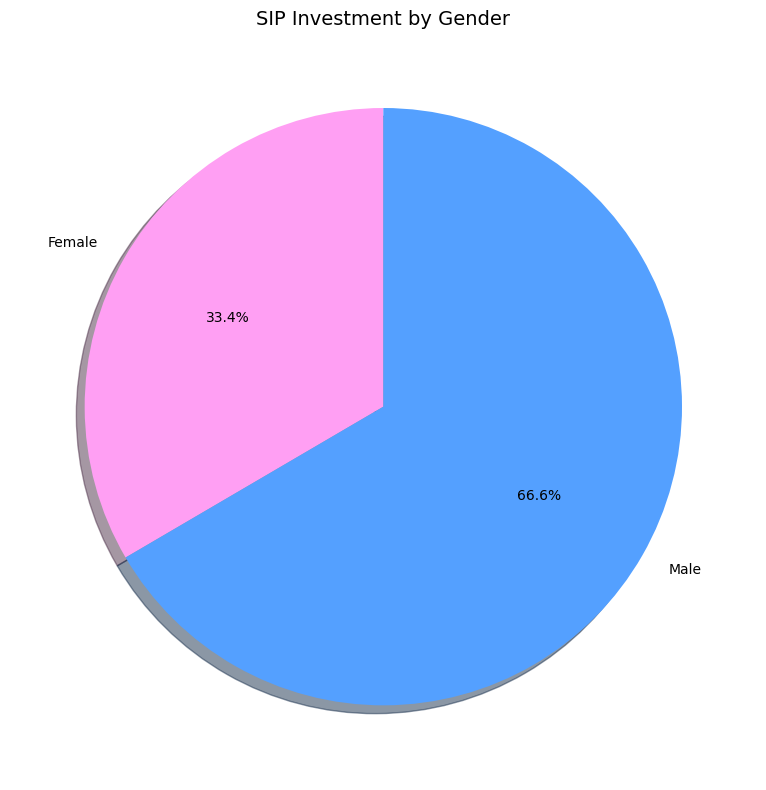

✅ Chart 12 saved!


In [62]:
# Cell 12 - Gender Split
gender_data = trans_df.groupby('gender')['amount_inr'].sum()

plt.figure(figsize=(8, 8))
plt.pie(gender_data.values,
        labels=gender_data.index,
        autopct='%1.1f%%',
        colors=['#FF9FF3', '#54A0FF'],
        startangle=90,
        shadow=True)

plt.title('SIP Investment by Gender', fontsize=14)
plt.tight_layout()
plt.savefig('reports/gender_split.png', dpi=150)
plt.show()
print("✅ Chart 12 saved!")

In [63]:
# Cell 13 - EDA Key Findings Summary
findings = """
## 📊 EDA Key Findings - Mutual Fund Analytics

1. **NAV Trend**: Consistent growth across all 40 schemes 2022-2026
2. **AUM Growth**: SBI dominates with ₹12.5L Cr AUM
3. **SIP Trend**: All-time high of ₹31,002 Cr in Dec 2025
4. **Category Heatmap**: Equity funds dominate inflows
5. **Age Distribution**: 30-45 age group highest investors
6. **SIP Box Plot**: Higher amounts from 35-50 age group
7. **Geographic**: Maharashtra and Delhi top states
8. **City Tier**: T30 cities contribute 65% of SIP
9. **Folio Growth**: 13.26 Cr to 26.12 Cr (2022-2025)
10. **Correlation**: Large cap funds highly correlated
"""
print(findings)
print("✅ All 12 charts completed!")
print("✅ All PNG files saved in reports/ folder!")


## 📊 EDA Key Findings - Mutual Fund Analytics

1. **NAV Trend**: Consistent growth across all 40 schemes 2022-2026
2. **AUM Growth**: SBI dominates with ₹12.5L Cr AUM
3. **SIP Trend**: All-time high of ₹31,002 Cr in Dec 2025
4. **Category Heatmap**: Equity funds dominate inflows
5. **Age Distribution**: 30-45 age group highest investors
6. **SIP Box Plot**: Higher amounts from 35-50 age group
7. **Geographic**: Maharashtra and Delhi top states
8. **City Tier**: T30 cities contribute 65% of SIP
9. **Folio Growth**: 13.26 Cr to 26.12 Cr (2022-2025)
10. **Correlation**: Large cap funds highly correlated

✅ All 12 charts completed!
✅ All PNG files saved in reports/ folder!
